In [69]:
import pysam
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.path import Path
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
import numpy as np

In [34]:
chrom='chr5'
region_start=97560000
region_end=97700000
target_gene = 'LIX1'
longhap = pysam.AlignmentFile('/scratch/gpfs/AKEY/apfennig/LongHap/hifi_reads_to_hs1.minimap2.hifi.chr5.longhap_indels_haplotagged.bam')
longhap_haps = {1: [], 2: [], 'unassigned': []}
for read in longhap.fetch(chrom, start=region_start, end=region_end):
    start = read.reference_start
    end = read.reference_end
    if read.has_tag('HP'):
        hap = read.get_tag('HP')
        longhap_haps[hap].append((start, end))
    else:
        longhap_haps['unassigned'].append((start, end))

In [3]:
longhap_meth = pysam.AlignmentFile('/scratch/gpfs/AKEY/apfennig/LongHap/hifi_reads_to_hs1.minimap2.hifi.chr5.longhap_meth_indels_haplotagged.bam')
longhap_meth_haps = {1: [], 2: [], 'unassigned': []}
for read in longhap_meth.fetch(chrom, start=region_start, end=region_end):
    start = read.reference_start
    end = read.reference_end
    if read.has_tag('HP'):
        hap = read.get_tag('HP')
        longhap_meth_haps[hap].append((start, end))
    else:
        longhap_meth_haps['unassigned'].append((start, end))
    

In [4]:
longhap_blocks = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/deepvariant/deep_variant_hifi_hs1.minimap2.hifi.chr5.filtered_snps_indels.longhap_blocks.bed',
                             sep='\t', names=['chrom', 'start', 'end'])
longhap_meth_blocks = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/deepvariant/deep_variant_hifi_hs1.minimap2.hifi.chr5.filtered_snps_indels.longhap_meth_blocks.bed',
                             sep='\t', names=['chrom', 'start', 'end'])

In [42]:
# gff3 = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/reference/chm13.draft_v2.0.gene_annotation.gff3',
#                     sep='\t', usecols=[0, 2, 3, 4, 8], names=['chrom', 'element', 'start', 'end', 'attributes'], 
#                     skiprows=1, engine='pyarrow')

# gff3 = gff3[(gff3.chrom == chrom) & (gff3.end > region_start) & (gff3.start < region_end)]
exons = gff3[gff3.element == 'exon']
genes = gff3[gff3.element == 'gene']
genes['gene_name'] = [attribute.split(';')[0].split('=')[1] for attribute in genes.attributes]
exons['gene_name'] = [attribute.split('gene_name=')[1].split(';')[0] for attribute in exons.attributes]
exons = exons[exons.gene_name == target_gene]
genes = genes[genes.gene_name == target_gene]

/tmp/ipykernel_3321222/4085891681.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genes['gene_name'] = [attribute.split(';')[0].split('=')[1] for attribute in genes.attributes]
/tmp/ipykernel_3321222/4085891681.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exons['gene_name'] = [attribute.split('gene_name=')[1].split(';')[0] for attribute in exons.attributes]


Rectangle(xy=(9.75926e+07, 4), width=3169, height=2, angle=0)
Rectangle(xy=(9.75976e+07, 4), width=77, height=2, angle=0)
Rectangle(xy=(9.7606e+07, 4), width=95, height=2, angle=0)
Rectangle(xy=(9.76081e+07, 4), width=140, height=2, angle=0)
Rectangle(xy=(9.76082e+07, 4), width=16, height=2, angle=0)
Rectangle(xy=(9.76252e+07, 4), width=163, height=2, angle=0)
Rectangle(xy=(9.76252e+07, 4), width=163, height=2, angle=0)
Rectangle(xy=(9.76379e+07, 4), width=88, height=2, angle=0)
Rectangle(xy=(9.76433e+07, 4), width=116, height=2, angle=0)
Rectangle(xy=(9.76433e+07, 4), width=258, height=2, angle=0)


Text(0, 0.5, 'LongHap')

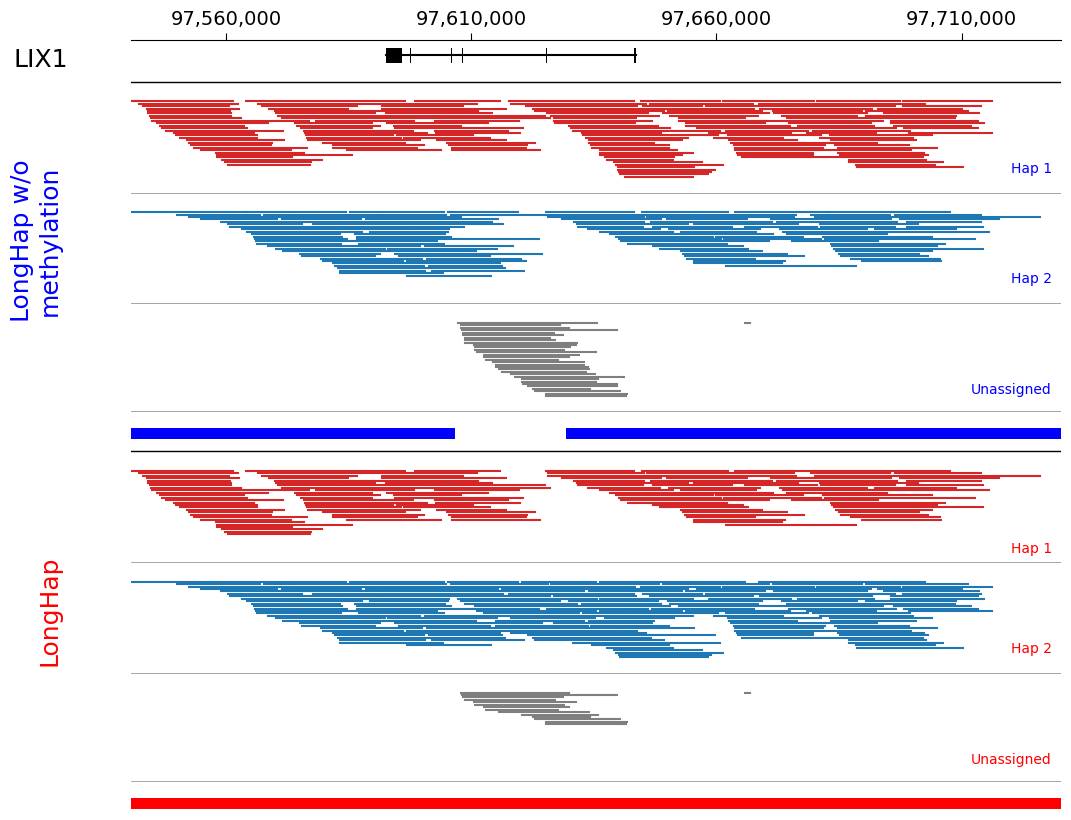

In [104]:
def assign_row(read_start, read_end):
    for i, last_end in enumerate(rows):
        if read_start > last_end:
            rows[i] = read_end   # ✅ update with END
            return i
    rows.append(read_end)
    return len(rows) - 1

rows = []

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(21, 1, figure=fig)

ax1 = fig.add_subplot(gs[1:4, :])
ax2 = fig.add_subplot(gs[4:7, :], sharex=ax1, sharey=ax1)
ax3 = fig.add_subplot(gs[7:10, :], sharex=ax1, sharey=ax1)
ax7 = fig.add_subplot(gs[10, :], sharex=ax1)


ax4 = fig.add_subplot(gs[11:14, :], sharex=ax1, sharey=ax1)
ax5 = fig.add_subplot(gs[14:17, :], sharex=ax1, sharey=ax1)
ax6 = fig.add_subplot(gs[17:20, :], sharex=ax1, sharey=ax1)
ax8 = fig.add_subplot(gs[20, :], sharex=ax1)
ax0 = fig.add_subplot(gs[0, :])

rows = []
for i, (start, end) in enumerate(longhap_haps[1]):
    row = assign_row(start, end)
    ax1.plot([start, end], [row, row], color='tab:red')
ax1.invert_yaxis()
ax1.spines[:].set_visible(False)
ax1.set_xticks([])
ax1.set_xticklabels([])
ax1.set_yticks([])
ax1.set_yticklabels([])
ax1.text(0.99, 0.2, 'Hap 1', transform=ax1.transAxes, ha='right', va='top', color='blue')
ax1.axhline(-8, ls='-', color='black', lw=1)

rows = []
for i, (start, end) in enumerate(longhap_haps[2]):
    row = assign_row(start, end)
    ax2.plot([start, end], [row, row], color='tab:blue')
ax2.spines[:].set_visible(False)
ax2.set_yticks([])
ax2.set_yticklabels([])
ax2.axhline(-8, ls='-', color='grey', lw=0.5)
ax2.text(0.99, 0.2, 'Hap 2', transform=ax2.transAxes, ha='right', va='top', color='blue')


rows = []
for i, (start, end) in enumerate(longhap_haps['unassigned']):
    row = assign_row(start, end)
    ax3.plot([start, end], [row, row], color='tab:grey')
ax3.spines[:].set_visible(False)
ax3.set_yticks([])
ax3.set_yticklabels([])
ax3.axhline(-8, ls='-', color='grey', lw=0.5)
ax3.text(0.99, 0.2, 'Unassigned', transform=ax3.transAxes, ha='right', va='top', color='blue')


overlapping_blocks = longhap_blocks[(longhap_blocks.end > region_start) & 
                                    (longhap_blocks.start < region_end)]
for idx, block in overlapping_blocks.iterrows():
    patch = patches.Rectangle((block['start'], 0), block['end'] - block['start'], 5,
                             facecolor='blue')
    ax7.add_patch(patch)
ax7.spines[:].set_visible(False)
ax7.set_xticks([])
ax7.set_xticklabels([])
ax7.set_yticks([])
ax7.set_yticklabels([])    
ax7.axhline(-8, ls='-', color='grey', lw=0.5)
ax7.invert_yaxis()



rows = []
for i, (start, end) in enumerate(longhap_meth_haps[1]):
    row = assign_row(start, end)
    ax4.plot([start, end], [row, row], color='tab:red')
ax4.spines[:].set_visible(False)
ax4.set_xticks([])
ax4.set_xticklabels([])
ax4.set_yticks([])
ax4.set_yticklabels([])
ax4.text(0.99, 0.1, 'Hap 1', transform=ax4.transAxes, ha='right', va='top', color='red')
ax4.axhline(-8, ls='-', color='black', lw=1)



rows = []
for i, (start, end) in enumerate(longhap_meth_haps[2]):
    row = assign_row(start, end)
    ax5.plot([start, end], [row, row], color='tab:blue')
ax5.spines[:].set_visible(False)
ax5.axhline(-8, ls='-', color='grey', lw=0.5)

ax5.set_yticks([])
ax5.set_yticklabels([])
ax5.text(0.99, 0.2, 'Hap 2', transform=ax5.transAxes, ha='right', va='top', color='red')


rows = []
for i, (start, end) in enumerate(longhap_meth_haps['unassigned']):
    row = assign_row(start, end)
    ax6.plot([start, end], [row, row], color='tab:grey')
ax6.spines[:].set_visible(False)
ax6.set_yticks([])
ax6.set_yticklabels([])
ax6.text(0.99, 0.2, 'Unassigned', transform=ax6.transAxes, ha='right', va='top', color='red')
ax6.axhline(-8, ls='-', color='grey', lw=0.5)


overlapping_blocks = longhap_meth_blocks[(longhap_meth_blocks.end > region_start) & 
                                    (longhap_meth_blocks.start < region_end)]
for idx, block in overlapping_blocks.iterrows():
    patch = patches.Rectangle((block['start'], 0), block['end'] - block['start'], 5,
                             facecolor='red')
    ax8.add_patch(patch)
    
ax8.spines[:].set_visible(False)
ax8.set_xticks([])
ax8.set_xticklabels([])
ax8.set_yticks([])
ax8.set_yticklabels([])    
ax8.axhline(-8, ls='-', color='grey', lw=0.5)
ax8.invert_yaxis()


ax0.plot([genes.start.values[0], genes.end.values[0]], [5, 5], color='black')
for idx, exon in exons.iterrows():

    patch = patches.Rectangle((exon['start'], 4), exon['end'] - exon['start'], 2,
                             facecolor='black')
    print(patch)
    ax0.add_patch(patch)
    

ax0.spines[:].set_visible(False)
ax0.spines['top'].set_visible(True)
ax0.set_yticks([])
ax0.set_yticklabels([])
ax0.set_ylabel('LIX1', fontsize=18, rotation=0, labelpad=85, loc='bottom')
ax0.set_xticks(np.arange(region_start, region_end + 50000, 50000))
ax0.set_xticklabels([f'{tick:,}' for tick in np.arange(region_start, region_end + 50000, 50000)],
                    fontsize=14)
ax0.tick_params(
    top=True, labeltop=True,
    bottom=False, labelbottom=False,
    direction='out', length=5
)
ax0.xaxis.set_visible(True)



ax0.set_xlim([97540690, 97730304])
ax0.set_ylim([3, 7])
ax6.set_xlim([97540690, 97730304])

ax2.set_ylabel('LongHap w/o\nmethylation', fontsize=18, labelpad=50, color='blue')
ax5.set_ylabel('LongHap', fontsize=18, labelpad=50, color='red')